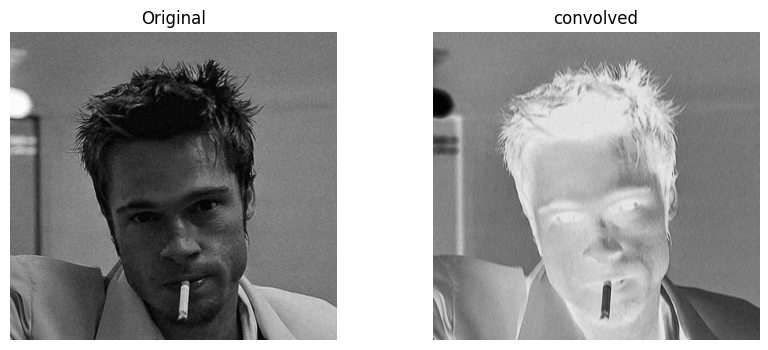

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage import color,io

raw_image = io.imread('/content/test.png')

if raw_image.ndim == 3:
    # If the image has an alpha channel (RGBA), drop it before conversion
    image = color.rgb2gray(raw_image[..., :3])
else:
    image = raw_image

# change filter numbers to see for yourself
 # eg. from whst i know
  #1. Increase the centre value to increase the brightness of the image.
#2. Change the negative values to positive to see how it affects the image.
#3. Changes in leftmost to negative shows left edges and vice-versa for right edges.
filter = np.array([[-2, 0, 0],
                   [-2, 1, 0],
                   [-2, 0, 0]])
#apply conv
convolved=convolve2d(image,filter,mode='same',boundary='symm')

#plot

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(image,cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('convolved')
plt.imshow(convolved,cmap='gray')
plt.axis('off')
plt.show()



### Pooling helps
1. converting the image to exactly half size without loosing(i mean loss happens, so if too much textures is required dont do it)....
2. also it removes the translation variance problem(makes location independent)
3. ...rest google it.

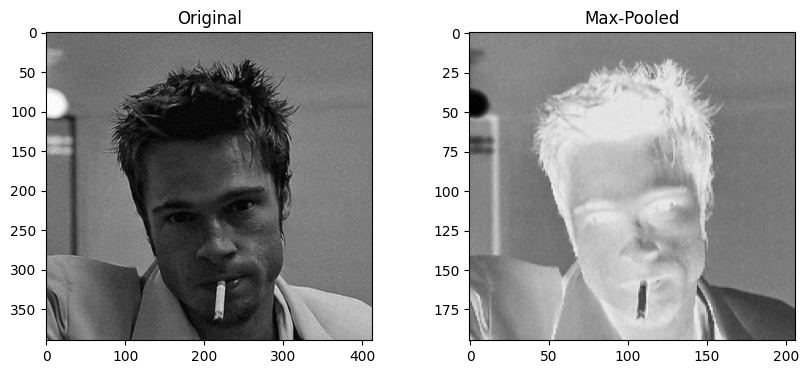

In [33]:
def max_pooling(feature_map, size=2, stride=2):
    output_shape = (
        (feature_map.shape[0] - size) // stride +   1,
        (feature_map.shape[1] - size) // stride + 1
    )
    pooled = np.zeros(output_shape)

    for i in range(output_shape[0]):
        for j in range(output_shape[1]):
            # Use i*stride : i*stride + size and j*stride : j*stride + size
            region = feature_map[
                i * stride : i * stride + size,
                j * stride : j * stride + size
            ]
            pooled[i, j] = np.max(region)

    return pooled

pooled_image = max_pooling(convolved, size=2, stride=2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(image, cmap='gray')
# plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Max-Pooled')
plt.imshow(pooled_image, cmap='gray')
# plt.axis('off')
plt.show()
